<a href="https://colab.research.google.com/github/sricharithathatavarthi/credit-card-/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load Kaggle dataset
df = pd.read_csv("creditcard.csv")

# Target variable
y = df['Class']   # 0 = non-fraud, 1 = fraud
X = df.drop('Class', axis=1)

print(df.head())
print(df['Class'].value_counts())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [2]:
# Time-based features
df['Hour'] = (df['Time'] // 3600) % 24
df['Day'] = df['Time'] // (3600*24)

# Behavioral features
df['Amount_zscore'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()
df['Rolling_mean'] = df['Amount'].rolling(window=10).mean().fillna(df['Amount'].mean())

# Risk features
df['High_value_flag'] = (df['Amount'] > 200).astype(int)

# Aggregated features
median_amount = df['Amount'].median()
df['Amount_ratio'] = df['Amount'] / median_amount

# Outlier score (Isolation Forest)
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.01, random_state=42)
df['Iso_score'] = iso.fit_predict(df[['Amount']])

# Final dataset
X = df.drop('Class', axis=1)
y = df['Class']


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Remove rows with NaN values in y
not_nan_indices = y.dropna().index
X = X.loc[not_nan_indices]
y = y.loc[not_nan_indices]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balance dataset with SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)


In [4]:
iso_model = IsolationForest(contamination=0.01, random_state=42)
iso_model.fit(X_train_scaled)
y_pred_iso = iso_model.predict(X_test_scaled)
y_pred_iso = [1 if p==-1 else 0 for p in y_pred_iso]  # -1 = anomaly → fraud


In [5]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
y_pred_lof = lof.fit_predict(X_test_scaled)
y_pred_lof = [1 if p==-1 else 0 for p in y_pred_lof]


In [6]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_bal, y_train_bal)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:59:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Confusion Matrix:
 [[20170     6]
 [    3    42]]
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     20176
         1.0       0.88      0.93      0.90        45

    accuracy                           1.00     20221
   macro avg       0.94      0.97      0.95     20221
weighted avg       1.00      1.00      1.00     20221



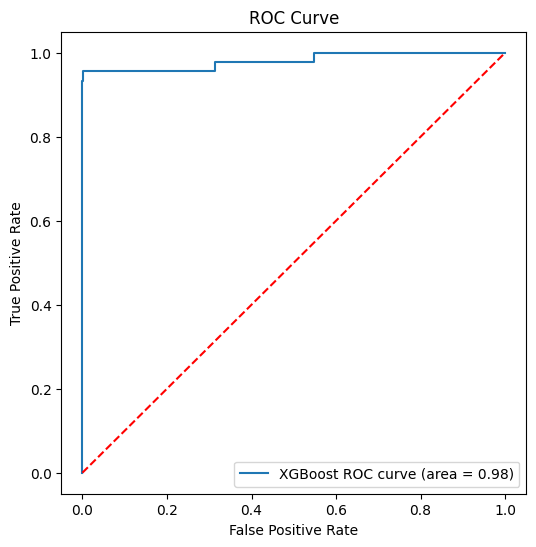

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Confusion Matrix
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'XGBoost ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [8]:
# streamlit_app.py
!pip install streamlit
import streamlit as st
import numpy as np

st.title("Credit Card Fraud Detection")

amount = st.number_input("Transaction Amount")
time = st.number_input("Transaction Time (seconds since first transaction)")

# Feature engineering for input
hour = (time // 3600) % 24
day = time // (3600*24)
amount_zscore = (amount - df['Amount'].mean()) / df['Amount'].std()
high_value_flag = int(amount > 200)
amount_ratio = amount / median_amount

# Fill missing V features with zeros (assuming V-features are centered around 0)
v_features = [0.0] * 28  # V1 to V28

# Calculate rolling mean (use overall mean as approximation for single transaction)
rolling_mean_val = df['Amount'].mean()

# Calculate Isolation Forest score for the input amount using the pre-trained `iso` model
# The `iso` model from cell e72-yLME3PkD was fitted on df[['Amount']] so it can predict for a single amount
iso_score_val = iso.predict(np.array([[amount]]))[0] # predict expects 2D array, take first result

# Construct the input data in the correct order of features as X_train
# Features order: Time, V1-V28, Amount, Hour, Day, Amount_zscore, Rolling_mean, High_value_flag, Amount_ratio, Iso_score
input_data_list = [
    time,
    *v_features,  # Unpack V1-V28
    amount,
    hour,
    day,
    amount_zscore,
    rolling_mean_val,
    high_value_flag,
    amount_ratio,
    iso_score_val
]

# Ensure input_data is a 2D array for scaler.transform
input_data_array = np.array([input_data_list])
input_scaled = scaler.transform(input_data_array)

prediction = xgb_model.predict(input_scaled)[0]
st.write("Prediction:", "Fraud" if prediction==1 else "Legit")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 93.8 MB/s eta 0:00:00


2026-06-29 09:59:26.636 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 09:59:26.879 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-29 09:59:26.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 09:59:26.882 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 09:59:26.885 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 09:59:26.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 09:59:26.889 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 09:59:26.890 Thread 'MainThread': mi

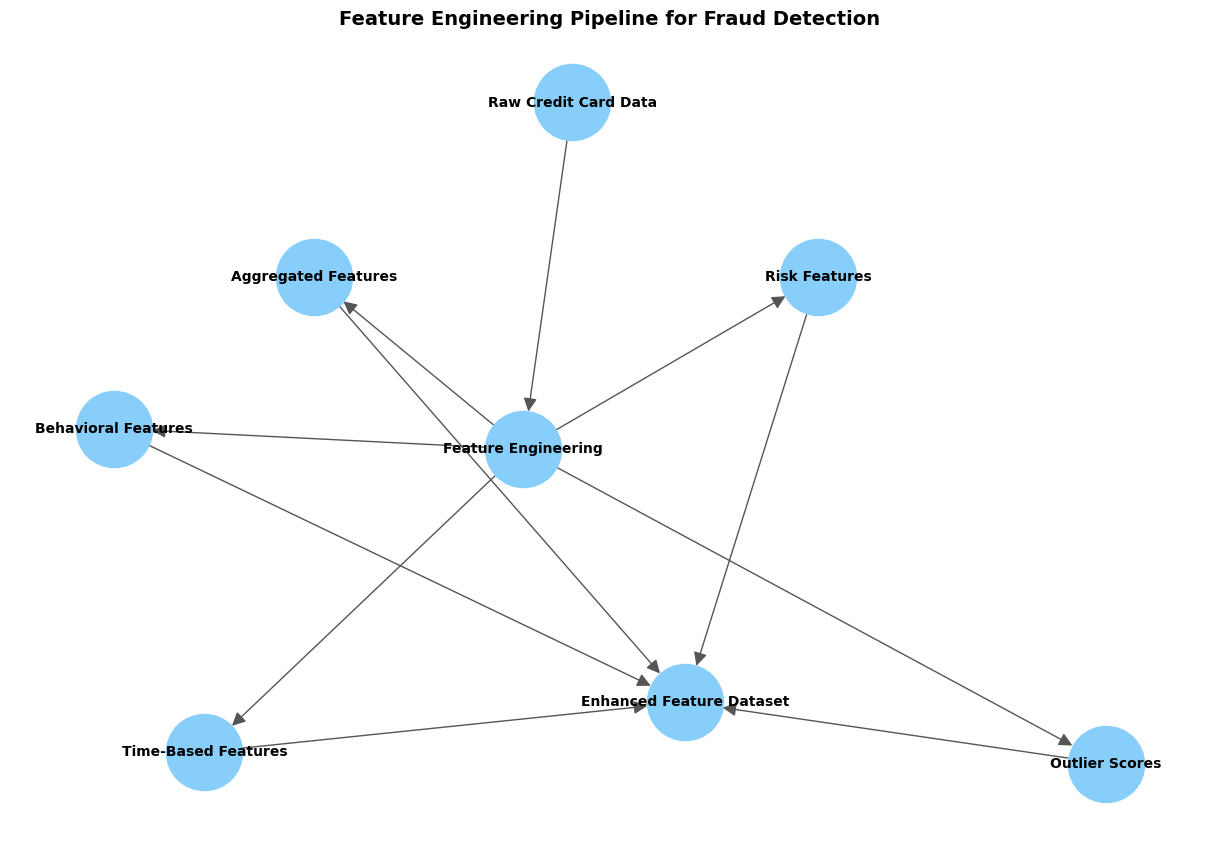

In [9]:
import matplotlib.pyplot as plt
import networkx as nx

# Create directed graph
G = nx.DiGraph()

# Nodes
nodes = [
    "Raw Credit Card Data",
    "Feature Engineering",
    "Time-Based Features",
    "Behavioral Features",
    "Risk Features",
    "Aggregated Features",
    "Outlier Scores",
    "Enhanced Feature Dataset"
]

G.add_nodes_from(nodes)

# Edges
edges = [
    ("Raw Credit Card Data", "Feature Engineering"),
    ("Feature Engineering", "Time-Based Features"),
    ("Feature Engineering", "Behavioral Features"),
    ("Feature Engineering", "Risk Features"),
    ("Feature Engineering", "Aggregated Features"),
    ("Feature Engineering", "Outlier Scores"),
    ("Time-Based Features", "Enhanced Feature Dataset"),
    ("Behavioral Features", "Enhanced Feature Dataset"),
    ("Risk Features", "Enhanced Feature Dataset"),
    ("Aggregated Features", "Enhanced Feature Dataset"),
    ("Outlier Scores", "Enhanced Feature Dataset")
]

G.add_edges_from(edges)

# Layout
pos = nx.spring_layout(G, seed=42)

# Draw nodes and edges
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color="#87CEFA", node_size=3000,
        font_size=10, font_weight='bold', arrowsize=20, edge_color="#555")

plt.title("Feature Engineering Pipeline for Fraud Detection", fontsize=14, fontweight='bold')
plt.show()


In [10]:
import pickle
pickle.dump(xgb_model, open('xgb_model.pkl','wb'))


In [11]:
import pickle

# Save model
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


In [12]:
from google.colab import files

files.download("xgb_model.pkl")
files.download("scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from google.colab import drive
drive.mount('/content/drive')

# Save into your Drive
pickle.dump(xgb_model, open("/content/drive/MyDrive/xgb_model.pkl", "wb"))
pickle.dump(scaler, open("/content/drive/MyDrive/scaler.pkl", "wb"))


Mounted at /content/drive


In [16]:
xgb_model = pickle.load(open("xgb_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))


In [18]:
import streamlit as st
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import pickle
import numpy as np # Added numpy import

# Load trained model and scaler
xgb_model = pickle.load(open("xgb_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("💳 Credit Card Fraud Detection")

amount = st.number_input("Transaction Amount")
time = st.number_input("Transaction Time (seconds since first transaction)")

# Feature engineering for input
hour = (time // 3600) % 24
day = time // (3600*24)

# Use df statistics for consistency with training
amount_zscore = (amount - df['Amount'].mean()) / df['Amount'].std()
high_value_flag = int(amount > 200)
amount_ratio = amount / median_amount

# Fill missing V features with zeros (assuming V-features are centered around 0)
v_features = [0.0] * 28  # V1 to V28

# Calculate rolling mean (use overall mean as approximation for single transaction)
rolling_mean_val = df['Amount'].mean()

# Calculate Isolation Forest score
iso_score_val = iso.predict(np.array([[amount]]))[0]

# Construct the input data in the correct order of features as X_train
# Features order: Time, V1-V28, Amount, Hour, Day, Amount_zscore, Rolling_mean, High_value_flag, Amount_ratio, Iso_score
input_data_list = [
    time,
    *v_features,  # Unpack V1-V28
    amount,
    hour,
    day,
    amount_zscore,
    rolling_mean_val,
    high_value_flag,
    amount_ratio,
    iso_score_val
]

# Ensure input_data is a 2D array for scaler.transform
input_data_array = np.array([input_data_list])
input_scaled = scaler.transform(input_data_array)

prediction = xgb_model.predict(input_scaled)[0]
st.success("Prediction: Fraudulent Transaction ⚠️" if prediction == 1 else "Prediction: Legitimate ✅")

2026-06-29 10:16:22.596 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 10:16:22.597 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 10:16:22.597 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 10:16:22.598 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 10:16:22.600 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 10:16:22.601 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 10:16:22.603 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 10:16:22.605 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import pickle
import numpy as np

# Load trained model and scaler
xgb_model = pickle.load(open("xgb_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("💳 Credit Card Fraud Detection")

amount = st.number_input("Transaction Amount")
time = st.number_input("Transaction Time (seconds since first transaction)")

# Feature engineering for input
hour = (time // 3600) % 24
day = time // (3600*24)

# Use df statistics for consistency with training
amount_zscore = (amount - df['Amount'].mean()) / df['Amount'].std()
high_value_flag = int(amount > 200)
amount_ratio = amount / median_amount

# Fill missing V features with zeros (assuming V-features are centered around 0)
v_features = [0.0] * 28  # V1 to V28

# Calculate rolling mean (use overall mean as approximation for single transaction)
rolling_mean_val = df['Amount'].mean()

# Calculate Isolation Forest score
iso_score_val = iso.predict(np.array([[amount]]))[0]

# Construct the input data in the correct order of features as X_train
# Features order: Time, V1-V28, Amount, Hour, Day, Amount_zscore, Rolling_mean, High_value_flag, Amount_ratio, Iso_score
input_data_list = [
    time,
    *v_features,
    amount,
    hour,
    day,
    amount_zscore,
    rolling_mean_val,
    high_value_flag,
    amount_ratio,
    iso_score_val
]

# Ensure input_data is a 2D array for scaler.transform
input_data_array = np.array([input_data_list])
input_scaled = scaler.transform(input_data_array)

prediction = xgb_model.predict(input_scaled)[0]
st.success("Prediction: Fraudulent Transaction ⚠️" if prediction == 1 else "Prediction: Legitimate ✅")

Writing app.py


In [22]:
import streamlit as st
st.title("Credit Card Fraud Detection")
# your UI + model loading code here


2026-06-29 10:24:00.830 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 10:24:00.834 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-29 10:24:00.840 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()